In [1]:
import pandas as pd

In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\PC\Desktop\solar\archive
['inverter_comparison.png', 'irradiation_vs_dcpower.png', 'Plant_1_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Generation_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', 'solar_analysis.ipynb']


In [3]:
gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
weather1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')


In [4]:
print(gen1.head())
print(weather1.head())

          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       0.0       0.0   
4  15-05-2020 00:00   4135001  McdE0feGgRqW7Ca       0.0       0.0   

   DAILY_YIELD  TOTAL_YIELD  
0          0.0    6259559.0  
1          0.0    6183645.0  
2          0.0    6987759.0  
3          0.0    7602960.0  
4          0.0    7158964.0  
             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135

In [5]:
print(gen1.shape)
print(gen1.columns)
print(weather1.shape)
print(weather1.columns)

(68778, 7)
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER',
       'DAILY_YIELD', 'TOTAL_YIELD'],
      dtype='str')
(3182, 6)
Index(['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION'],
      dtype='str')


In [6]:
print(gen1['SOURCE_KEY'].nunique())
print(weather1['SOURCE_KEY'].nunique())

22
1


In [7]:
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])

print(gen1['DATE_TIME'].head())
print(weather1['DATE_TIME'].head())

0   2020-05-15
1   2020-05-15
2   2020-05-15
3   2020-05-15
4   2020-05-15
Name: DATE_TIME, dtype: datetime64[us]
0   2020-05-15 00:00:00
1   2020-05-15 00:15:00
2   2020-05-15 00:30:00
3   2020-05-15 00:45:00
4   2020-05-15 01:00:00
Name: DATE_TIME, dtype: datetime64[us]


In [8]:
merged1 = pd.merge(gen1, weather1, on=['DATE_TIME', 'PLANT_ID'])
print(merged1.shape)
print(merged1.head())

(68774, 11)
   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    6183645.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6987759.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7602960.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    7158964.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3     

In [9]:
correlation = merged1['IRRADIATION'].corr(merged1['DC_POWER'])
print(correlation)

0.9893910408878296


In [10]:
inverter_avg = merged1.groupby('SOURCE_KEY_x')['DC_POWER'].mean().sort_values()
print(inverter_avg)

SOURCE_KEY_x
bvBOhCH3iADSZry    2828.998291
1BY6WEcLGh8j5v7    2873.720981
ih0vzX44oOqAx2f    3097.714161
z9Y9gH1T5YWrNuG    3132.497910
7JYdWkrLSPkdwr4    3132.891955
ZoEaEvLYb1n2sOq    3139.009808
sjndEbLyjtCKgGv    3148.270450
zBIq5rxdHJRwDNY    3148.590013
WRmjgnKYAwPKWDb    3155.384433
rGa61gmuvPhdLxV    3163.240929
pkci93gMrogZuBj    3166.599439
wCURE6d3bPkepu2    3169.304650
YxYtjZvoooNbGkE    3179.492570
zVJPv84UY57bAof    3187.236622
ZnxXDlPa8U1GXgE    3194.059104
uHbuxQJl8lW7ozc    3195.316080
iCRJl6heRkivqQ3    3196.074675
VHMLBKoKgIrUVDU    3210.102563
McdE0feGgRqW7Ca    3211.307245
3PZuoBAID5Wc2HD    3221.015673
1IF53ai7Xc0U56Y    3225.125523
adLQvlD726eNBSB    3268.305824
Name: DC_POWER, dtype: float64


In [11]:
merged1['HOUR'] = merged1['DATE_TIME'].dt.hour
hourly_avg = merged1.groupby('HOUR')['DC_POWER'].mean()
print(hourly_avg)

HOUR
0        0.000000
1        0.000000
2        0.000000
3        0.000000
4        0.000000
5        0.000000
6      578.113622
7     2551.386720
8     5088.628218
9     7247.398958
10    8720.411543
11    9805.565924
12    9731.281831
13    9232.377553
14    7977.783119
15    6457.881863
16    4082.438281
17    1756.366881
18     228.867923
19       0.000000
20       0.000000
21       0.000000
22       0.000000
23       0.000000
Name: DC_POWER, dtype: float64


In [12]:
gen2 = pd.read_csv('Plant_2_Generation_Data.csv')
weather2 = pd.read_csv('Plant_2_Weather_Sensor_Data.csv')

gen2['DATE_TIME'] = pd.to_datetime(gen2['DATE_TIME'])
weather2['DATE_TIME'] = pd.to_datetime(weather2['DATE_TIME'])

merged2 = pd.merge(gen2, weather2, on=['DATE_TIME', 'PLANT_ID'])

print("Plant 1 average DC_POWER:", merged1['DC_POWER'].mean())
print("Plant 2 average DC_POWER:", merged2['DC_POWER'].mean())

Plant 1 average DC_POWER: 3147.1774501376403
Plant 2 average DC_POWER: 246.7019608878177


In [13]:
print(merged1['DC_POWER'].describe())
print(merged2['DC_POWER'].describe())

count    68774.000000
mean      3147.177450
std       4036.441826
min          0.000000
25%          0.000000
50%        428.571429
75%       6365.468750
max      14471.125000
Name: DC_POWER, dtype: float64
count    67698.000000
mean       246.701961
std        370.569597
min          0.000000
25%          0.000000
50%          0.000000
75%        446.591667
max       1420.933333
Name: DC_POWER, dtype: float64


In [14]:
print(merged1['DC_POWER'].describe())
print(merged2['DC_POWER'].describe())

count    68774.000000
mean      3147.177450
std       4036.441826
min          0.000000
25%          0.000000
50%        428.571429
75%       6365.468750
max      14471.125000
Name: DC_POWER, dtype: float64
count    67698.000000
mean       246.701961
std        370.569597
min          0.000000
25%          0.000000
50%          0.000000
75%        446.591667
max       1420.933333
Name: DC_POWER, dtype: float64


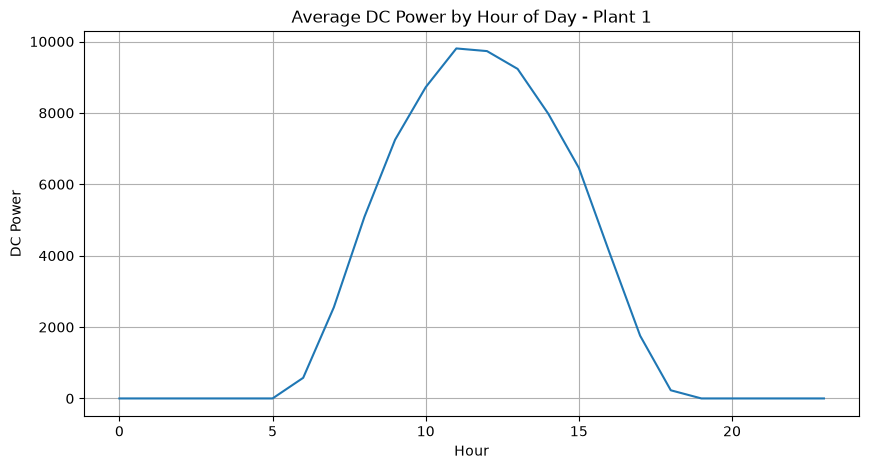

In [15]:
import matplotlib.pyplot as plt

hourly_avg.plot(kind='line', figsize=(10, 5))
plt.title('Average DC Power by Hour of Day - Plant 1')
plt.xlabel('Hour')
plt.ylabel('DC Power')
plt.grid(True)
plt.show()

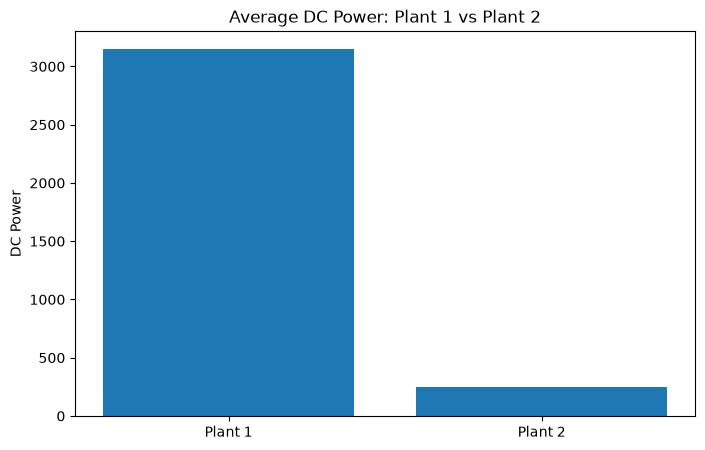

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(['Plant 1', 'Plant 2'], [merged1['DC_POWER'].mean(), merged2['DC_POWER'].mean()])
plt.title('Average DC Power: Plant 1 vs Plant 2')
plt.ylabel('DC Power')
plt.show()

In [17]:
print(f"Processed {len(merged1):,} records")
print(f"Data covers {merged1['DATE_TIME'].nunique()} unique timestamps")

Processed 68,774 records
Data covers 3157 unique timestamps


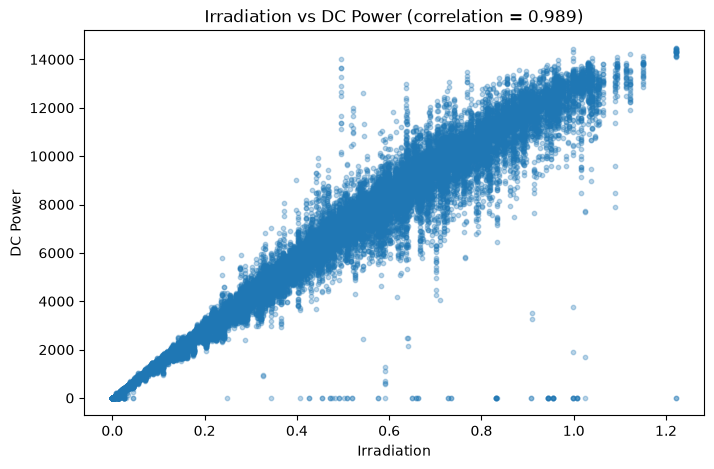

In [18]:
import matplotlib.pyplot as plt

# 1. Scatter plot: IRRADIATION vs DC_POWER (แสดง correlation 0.989)
plt.figure(figsize=(8, 5))
plt.scatter(merged1['IRRADIATION'], merged1['DC_POWER'], alpha=0.3, s=10)
plt.title(f'Irradiation vs DC Power (correlation = {correlation:.3f})')
plt.xlabel('Irradiation')
plt.ylabel('DC Power')
plt.savefig('irradiation_vs_dcpower.png', dpi=150, bbox_inches='tight')
plt.show()

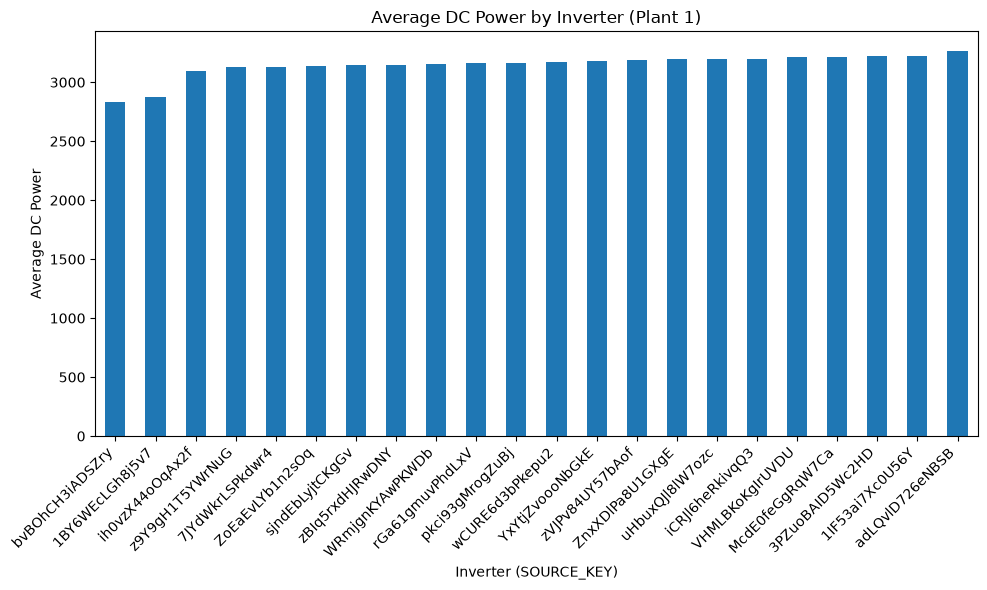

In [19]:
# 2. Bar chart: เปรียบเทียบ average DC_POWER ต่อ inverter (ใช้ inverter_avg ที่มีอยู่แล้ว)
plt.figure(figsize=(10, 6))
inverter_avg.plot(kind='bar')
plt.title('Average DC Power by Inverter (Plant 1)')
plt.xlabel('Inverter (SOURCE_KEY)')
plt.ylabel('Average DC Power')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('inverter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()